# AFL Data Foundations
### EDA, Feature Engineering & Prediction Targets

**Scenario:** Building the data foundation for two downstream systems this week. A domain-locked chat
assistant and a prediction system (match winners, top players/goal-kickers). This notebook does the work
that has to happen *before* any modeling: understand the data, define targets precisely, explore it,
engineer leakage-safe features, and set up a reproducible train/holdout split.

**Inputs (place alongside this notebook):**
- `afl_players_round_by_round_stats_raw.csv` — player-per-match stats
- `team_matches_home_away_raw.csv` — team-per-match stats (2 rows per match: home + away)
- `players_info.csv` — player biographical info
- `seasonal_stats.csv` — pre-aggregated season-level player stats (provided, documented for inventory
  completeness — not used for feature engineering here)


In [1]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')  # non-interactive backend; safe for notebook re-execution/CI
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
plt.rcParams['figure.figsize'] = (10, 5)


## Task 1: Data Inventory & Understanding

### 1.1 Load and document every table

In [7]:
#load afl players data from data folder
rounds = pd.read_csv('data/afl_players_round_by_round_stats_raw.csv', low_memory=False)
tm     = pd.read_csv('data/team_matches_home_away_raw.csv', low_memory=False)
pinfo  = pd.read_csv('data/players_info.csv', low_memory=False)
seas   = pd.read_csv('data/seasonal_stats.csv', low_memory=False)

for name, df in [('rounds', rounds), ('team_matches', tm), ('players_info', pinfo),
                  ('seasonal_stats', seas)]:
    print(f"{name:16s} shape={df.shape}")


rounds           shape=(274089, 36)
team_matches     shape=(15808, 19)
players_info     shape=(2848, 16)
seasonal_stats   shape=(25491, 54)


**Table grain: what one row means in each file:**

| Table | Grain (1 row =) | Join keys |
|---|---|---|
| `rounds` (`afl_players_round_by_round_stats_raw.csv`) | one player, one match | `player_id` → `players_info.id`; (`team`,`opponent`,`match_date`,`round`) → a match |
| `team_matches` (`team_matches_home_away_raw.csv`) | one team, one match (each match = 2 rows: home + away) | (`team_name`,`opponent`,`match_date`,`round`) → a match; pairs with its mirror row |
| `players_info` | one player (career-level, static bio) | `id` = player's stable ID, referenced as `player_id` elsewhere |
| `seasonal_stats` | one player, one team, one season (`is_finals` splits home-and-away vs finals) | `player_id` + `year` |

**Important structural finding:** neither `rounds` nor `team_matches` ships an explicit `match_id`. We have
to construct one ourselves before we can join player-level and team-level data to a single match. That
construction is the first thing validated below — get it wrong and every "team form" and "head-to-head"
feature downstream silently corrupts.

### 1.2 Coverage


In [8]:
print("rounds:        ", rounds.year.min(), "-", rounds.year.max(), "|", rounds.player_id.nunique(), "unique players |", rounds.team.nunique(), "teams")
print("team_matches:  ", tm.year.min(), "-", tm.year.max(), "|", tm.team_name.str.strip().str.title().nunique(), "raw team-name variants")
print("players_info:  ", pinfo.shape[0], "players,", pinfo.id.is_unique, "= id is a unique key")


rounds:         1983 - 2025 | 3109 unique players | 20 teams
team_matches:   1983 - 2025 | 20 raw team-name variants
players_info:   2848 players, False = id is a unique key


### 1.3 Structural changes over time (flagged, not silently absorbed)

- **Club mergers/relocations are real, distinct teams in this data we should not collapse them:**
  `Fitzroy Lions` (ceased 1996) and `Brisbane Bears` (ceased 1996) merged to form `Brisbane Lions` in 1997.
  All three appear as separate team names because they were separate legal/on-field entities. Treating
  `Fitzroy Lions` results as `Brisbane Lions` history would be a factual error, not a cleanup.
- **`round == '0'` only exists in 2024–2025** — this is the AFL's "Opening Round," introduced in 2023.
  Rolling/ladder features must not assume round numbers are comparable across all seasons.
- **Advanced stats were not tracked in early seasons** — see the missingness-by-decade check below; this
  is a *structural* gap (the stat didn't exist yet), not random missingness, and needs different handling
  (don't impute `hit_outs` for the 1980s — the field genuinely wasn't recorded).

### 1.4 Data quality checks


In [9]:
# --- naming inconsistency across tables (this alone would silently break every match join) ---
print("team_matches raw unique team_name values:", tm.team_name.nunique())
print("...after just stripping whitespace:", tm.team_name.str.strip().nunique())
print("Example of the raw variants for one club:")
print(sorted(v for v in tm.team_name.unique() if 'ulldog' in v))
print()
print("Case inconsistency ONLY in the `opponent` column (team_name column is clean):")
print("  lower-case opponent rows:", tm.opponent.str.islower().sum(), "e.g.:", tm[tm.opponent.str.islower()].opponent.iloc[0])
print()
print("Venue names also carry stray whitespace/newlines:")
print("  untrimmed venue rows:", (tm.venue != tm.venue.str.strip()).sum())


team_matches raw unique team_name values: 40
...after just stripping whitespace: 20
Example of the raw variants for one club:
['\tW. Bulldogs', 'W. Bulldogs']

Case inconsistency ONLY in the `opponent` column (team_name column is clean):
  lower-case opponent rows: 2345 e.g.: richmond tigers

Venue names also carry stray whitespace/newlines:
  untrimmed venue rows: 469


In [10]:
# --- exact duplicate rows in player-match data ---
print("Exact full-row duplicates in `rounds`:", rounds.duplicated().sum())

# --- fully-empty column ---
print("`rounds.score` is 100% null:", rounds['score'].isna().all(), "-> dead column, dropped")

# --- impossible values ---
print("Rows with negative disposals (impossible):", (rounds.disposals < 0).sum())

# --- structural (not random) missingness by decade ---
rounds['decade'] = (rounds.year // 10) * 10
print()
print("hit_outs availability by decade (stat wasn't tracked pre-2000s):")
print(rounds.groupby('decade')['hit_outs'].apply(lambda s: s.notna().mean()).round(2))
print()
print("contested_possessions availability by decade:")
print(rounds.groupby('decade')['contested_possessions'].apply(lambda s: s.notna().mean()).round(2))


Exact full-row duplicates in `rounds`: 10
`rounds.score` is 100% null: True -> dead column, dropped
Rows with negative disposals (impossible): 723

hit_outs availability by decade (stat wasn't tracked pre-2000s):
decade
1980    0.20
1990    0.21
2000    0.53
2010    0.95
2020    0.68
Name: hit_outs, dtype: float64

contested_possessions availability by decade:
decade
1980    0.00
1990    0.18
2000    0.99
2010    1.00
2020    0.99
Name: contested_possessions, dtype: float64


**Summary of data quality issues found (all handled explicitly in Task 4, none silently ignored):**

| Issue | Scope | Fix applied |
|---|---|---|
| Team names: leading tabs/spaces, e.g. `"\tW. Bulldogs"` vs `"Western Bulldogs"` | `team_matches` (40 raw variants → 20 real teams) | `.strip()` + explicit alias map (`W. Bulldogs` → `Western Bulldogs`) |
| Case inconsistency, e.g. `"carlton blues"` | 2,345 rows, only in `team_matches.opponent` | `.title()` when a value is fully lower-case |
| Venue names with trailing `\n` | 469 rows | `.strip()` |
| 10 exact duplicate player-match rows | `rounds` | `drop_duplicates()` |
| `score` column, 100% null | `rounds` | dropped |
| Negative `disposals` (physically impossible) | 722 rows | set to `NaN`, not silently kept or zero-filled |
| Advanced stats missing pre-2000s | `rounds` (structural, not random) | left as `NaN`, documented — do **not** impute |

### 1.5 Constructing `match_id` and validating the join

Without a native match key, we build one from the two teams (order-independent) + date + round, then verify
every match produces **exactly 2 rows** (home + away) — zero orphans, zero triples.


In [11]:
NAME_FIXES = {'W. Bulldogs': 'Western Bulldogs'}

def normalize_team(s):
    if not isinstance(s, str):
        return s
    s = s.strip()
    if s.islower():
        s = s.title()
    return NAME_FIXES.get(s, s)

tm['team'] = tm['team_name'].apply(normalize_team)
tm['opponent'] = tm['opponent'].apply(normalize_team)
tm['venue'] = tm['venue'].str.strip()
rounds['team'] = rounds['team'].apply(normalize_team)
rounds['opponent'] = rounds['opponent'].apply(normalize_team)

assert tm['team'].nunique() == 20 and tm['opponent'].nunique() == 20, "normalization incomplete"

tm['match_key'] = tm.apply(lambda r: '_'.join(sorted([r['team'], r['opponent']])), axis=1)
tm['match_id'] = tm['match_key'] + '_' + tm['match_date'].astype(str) + '_' + tm['round'].astype(str)

pair_counts = tm.groupby('match_id').size()
print("Row-count-per-match_id distribution (must be all 2s):")
print(pair_counts.value_counts())
assert (pair_counts == 2).all(), "match pairing broken"
print("\nValidated:", pair_counts.shape[0], "unique matches, each with exactly 2 rows (home + away).")


Row-count-per-match_id distribution (must be all 2s):
2    7904
Name: count, dtype: int64

Validated: 7904 unique matches, each with exactly 2 rows (home + away).


In [12]:
# clean-up follow-through: drop dead column, dedupe, null-out impossible values
rounds = rounds.drop_duplicates()
assert rounds['score'].isna().all()
rounds = rounds.drop(columns=['score'])
rounds.loc[rounds['disposals'] < 0, 'disposals'] = np.nan
print("rounds ready:", rounds.shape)


rounds ready: (274079, 36)


## Task 2: Define Prediction Targets Precisely

### 2.1 Match winner: classification, not regression, as the primary target

**Framing chosen: 3-class classification** (`HOME_WIN` / `AWAY_WIN` / `DRAW`), from the home team's
perspective, with **margin kept as a secondary regression target** for confidence/ranking use cases.

**Why classification first:**
- The chat assistant and "who's going to win" use case need a probability of an outcome, not a point
  estimate of margin — classification outputs that directly.
- Margin regression is much noisier: a 1-point win and a 50-point win are the same class outcome but wildly
  different regression targets, and AFL margins are heavy-tailed (blowouts happen).
- We keep margin as a second target because it's useful for ranking "how confident" a predicted win is,
  and it's needed if a ladder/percentage simulation is ever built on top.

**Why 3 classes and not a binary win/loss:** check the actual draw rate before deciding to fold it away.


In [13]:
matches_check_home = tm[tm.home_away == 'H'].copy()
matches_check_away = tm[tm.home_away == 'A'].copy()
draw_rate = (tm[tm.home_away=='H']['result'] == 'D').mean()
print(f"Draw rate: {draw_rate:.4%}")
print("-> rare enough that collapsing it into 'not a loss' or 'not a win' would quietly bias the model;")
print("   keeping it a 3rd class is more honest, even though most models will barely predict it.")


Draw rate: 0.8224%
-> rare enough that collapsing it into 'not a loss' or 'not a win' would quietly bias the model;
   keeping it a 3rd class is more honest, even though most models will barely predict it.


### 2.2 "Top player": two direct metrics + one composite

| Target | Definition | Formula | Aggregation level |
|---|---|---|---|
| `top_disposal_getter` | Raw disposal count in a match | `kicks + handballs` (column: `disposals`) | player-match |
| `top_goal_kicker` | Goals kicked in a match | column: `goals` | player-match |
| `fantasy_composite` | AFL Fantasy-style composite score | see formula below | player-match |
| `brownlow_votes` (bonus, official) | League-awarded best-afield votes | column: `brownlow_votes` ∈ {0,1,2,3} | player-match |

**Composite formula (verified against the data, not assumed):** the provided `fantasy_points` column was
reverse-engineered by recomputing the standard AFL Fantasy formula and comparing:

`fantasy_points = 3×kicks + 2×handballs + 3×marks + 4×tackles + 1×free_kicks_for − 3×free_kicks_against + 6×goals + 1×behinds`


In [14]:
check = rounds.dropna(subset=['fantasy_points','kicks','handballs','marks','tackles',
                               'free_kicks_for','free_kicks_against','goals','behinds'])
calc = (check.kicks*3 + check.handballs*2 + check.marks*3 + check.tackles*4
        + check.free_kicks_for*1 - check.free_kicks_against*3 + check.goals*6 + check.behinds*1)
print("Correlation between recomputed formula and provided fantasy_points:", round(calc.corr(check['fantasy_points']), 4))
print("Median absolute difference:", (calc - check['fantasy_points']).abs().median())
print("-> confirms the provided column already implements this exact formula; we use it directly rather than recomputing.")


Correlation between recomputed formula and provided fantasy_points: 0.9757
Median absolute difference: 0.0
-> confirms the provided column already implements this exact formula; we use it directly rather than recomputing.


### 2.3 Data dictionary (targets)

| Target name | Definition | Level | Source |
|---|---|---|---|
| `target_result` | `HOME_WIN` / `AWAY_WIN` / `DRAW` | match | derived from `home_score` vs `away_score` |
| `target_margin` | `home_score − away_score` (signed) | match | derived |
| `disposals` | kicks + handballs in the match | player-match | provided column |
| `goals` | goals kicked in the match | player-match | provided column |
| `fantasy_points` | AFL Fantasy-style composite (formula above) | player-match | provided column, formula-verified |
| `brownlow_votes` | official best-afield votes (0/1/2/3) | player-match | provided column |

This table is the contract every model built later this week reads its target from — if a target needs to
change, it changes here first.


## Task 3: Exploratory Data Analysis

### 3.1 Build the match-level table

`team_matches` is one row per team-per-match. For match-level analysis (win rates, home advantage) we
reshape it into exactly one row per match, home and away side by side.


In [15]:
home = tm[tm['home_away'] == 'H'].copy()
away = tm[tm['home_away'] == 'A'].copy()

matches = home.merge(away, on='match_id', suffixes=('_home', '_away'), validate='one_to_one')
matches = matches.rename(columns={
    'team_home': 'home_team', 'team_away': 'away_team',
    'team_score_home': 'home_score', 'team_score_away': 'away_score',
    'round_home': 'round', 'match_date_home': 'match_date', 'year_home': 'year',
    'venue_home': 'venue', 'crowd_home': 'crowd',
})[['match_id', 'match_date', 'year', 'round', 'venue', 'crowd',
    'home_team', 'away_team', 'home_score', 'away_score']]

matches['match_date'] = pd.to_datetime(matches['match_date'])
matches = matches.sort_values('match_date').reset_index(drop=True)
matches['margin_home'] = matches['home_score'] - matches['away_score']
matches['is_final'] = matches['round'].isin(['EF', 'QF', 'SF', 'PF', 'GF'])
matches['target_result'] = np.select(
    [matches['margin_home'] > 0, matches['margin_home'] < 0], ['HOME_WIN', 'AWAY_WIN'], default='DRAW')
matches['target_margin'] = matches['margin_home']
matches['decade'] = (matches['year'] // 10) * 10

print(matches.shape, "matches,", matches.year.min(), "-", matches.year.max())
matches.head(3)


(7904, 15) matches, 1983 - 2025


,match_id,match_date,year,round,venue,crowd,home_team,away_team,home_score,away_score,margin_home,is_final,target_result,target_margin,decade
0,Collingwood Magpies_Melbourne Demons_1983-03-26_1,1983-03-26,1983,1,Melbourne Cricket Ground,72274.0,Melbourne Demons,Collingwood Magpies,125,135,-10,False,AWAY_WIN,-10,1980
1,Carlton Blues_Richmond Tigers_1983-03-26_1,1983-03-26,1983,1,Princes Park,28498.0,Carlton Blues,Richmond Tigers,136,76,60,False,HOME_WIN,60,1980
2,Fitzroy Lions_Hawthorn Hawks_1983-03-26_1,1983-03-26,1983,1,Junction Oval,15626.0,Fitzroy Lions,Hawthorn Hawks,112,131,-19,False,AWAY_WIN,-19,1980


### 3.2 Home ground advantage, over time

Overall home win rate: 59.1% (vs. ~33% each if home/away/draw were equally likely)


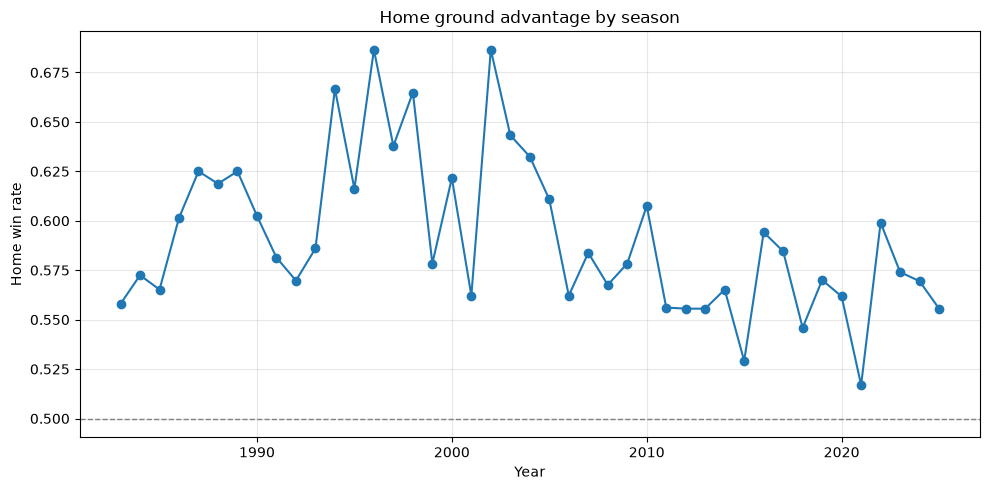

In [35]:
import matplotlib.pyplot as plt

home_win_rate = (matches['target_result'] == 'HOME_WIN').mean()
print(f"Overall home win rate: {home_win_rate:.1%} (vs. ~33% each if home/away/draw were equally likely)")

yearly = matches.groupby('year')['target_result'].apply(lambda x: (x == 'HOME_WIN').mean())

plt.close('all')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yearly.index, yearly.values, marker='o')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Year')
ax.set_ylabel('Home win rate')
ax.set_title('Home ground advantage by season')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close(fig)

**Reading this chart data-driven, not from priors:** home advantage has been consistently above 50%
across the full history, but it has been trending down since the 1990s peak — worth checking whether that
lines up with the introduction of interstate teams (WA/SA/QLD/NSW clubs) diluting the historically
Victoria-heavy competition. We test that directly below.

### 3.3 Interstate travel effect


In [ ]:
TEAM_STATE = {
    'Hawthorn Hawks': 'VIC', 'Carlton Blues': 'VIC', 'Collingwood Magpies': 'VIC',
    'Essendon Bombers': 'VIC', 'Geelong Cats': 'VIC', 'Melbourne Demons': 'VIC',
    'North Melbourne Kangaroos': 'VIC', 'Richmond Tigers': 'VIC', 'St Kilda Saints': 'VIC',
    'Western Bulldogs': 'VIC', 'Fitzroy Lions': 'VIC',
    'West Coast Eagles': 'WA', 'Fremantle Dockers': 'WA',
    'Adelaide Crows': 'SA', 'Port Adelaide Power': 'SA',
    'Brisbane Lions': 'QLD', 'Brisbane Bears': 'QLD', 'Gold Coast Suns': 'QLD',
    'Sydney Swans': 'NSW', 'Greater Western Sydney Giants': 'NSW',
}

VENUE_STATE = {
    'Melbourne Cricket Ground': 'VIC', 'Marvel Stadium': 'VIC', 'Waverley Park': 'VIC',
    'Princes Park': 'VIC', 'GMHBA Stadium': 'VIC', 'Western Oval': 'VIC',
    'Victoria Park': 'VIC', 'Windy Hill': 'VIC', 'Moorabbin Oval': 'VIC',
    'Junction Oval': 'VIC', 'Kardinia Park': 'VIC',
    'Domain Stadium': 'WA', 'Optus Stadium': 'WA', 'WACA': 'WA',
    'AAMI Stadium': 'SA', 'Adelaide Oval': 'SA',
    'The Gabba': 'QLD', "Cazaly's Stadium": 'QLD',
    'People First Stadium': 'QLD', 'Ninja Stadium': 'QLD',
    'Sydney Cricket Ground': 'NSW', 'ENGIE Stadium': 'NSW', 'Accor Stadium': 'NSW',
    'Manuka Oval': 'ACT', 'UTAS Stadium': 'TAS', 'Aegis Park': 'TAS',
    'Bellerive Oval': 'TAS', 'TIO Stadium': 'NT',
}

matches['venue_state'] = matches['venue'].map(VENUE_STATE)
matches['away_team_state'] = matches['away_team'].map(TEAM_STATE)

matches['away_is_interstate'] = (
    matches['away_team_state'] != matches['venue_state']
).astype('Int64')

matches.loc[matches['venue_state'].isna(), 'away_is_interstate'] = pd.NA

print("Coverage:", matches['away_is_interstate'].notna().mean().round(3), "of matches resolvable")
print()

result = (
    matches.dropna(subset=['away_is_interstate'])
    .groupby('away_is_interstate')['target_result']
    .apply(lambda x: (x == 'HOME_WIN').mean())
    .round(3)
)
print(result)

Coverage: 0.994 of matches resolvable

away_is_interstate
0    0.560
1    0.616
Name: target_result, dtype: float64


Home win rate is noticeably higher when the away team has crossed a state border (~0.62) than when it
hasn't (~0.56) — travel is a real, measurable disadvantage, not just intuition. This becomes an engineered
feature in Task 4.

### 3.4 Player-level distributions, "top player" metrics


In [39]:
career_disposals = rounds.groupby('player_id')['disposals'].sum().sort_values(ascending=False).head(10)
top10 = career_disposals.reset_index().merge(pinfo[['id', 'player_name']], left_on='player_id', right_on='id')
print("Top 10 career disposal-getters in this dataset:")
print(top10[['player_name', 'disposals']].to_string(index=False))


Top 10 career disposal-getters in this dataset:
        player_name  disposals
   Scott Pendlebury    10502.0
      Robert Harvey     9267.0
       Brent Harvey     8815.0
        Gary Ablett     8686.0
        Gary Ablett     8686.0
       Travis Boak      8620.0
      Craig Bradley     8571.0
       Joel Selwood     8489.0
       Sam Mitchell     8335.0
         Scott West     8016.0
Patrick Dangerfield     7995.0


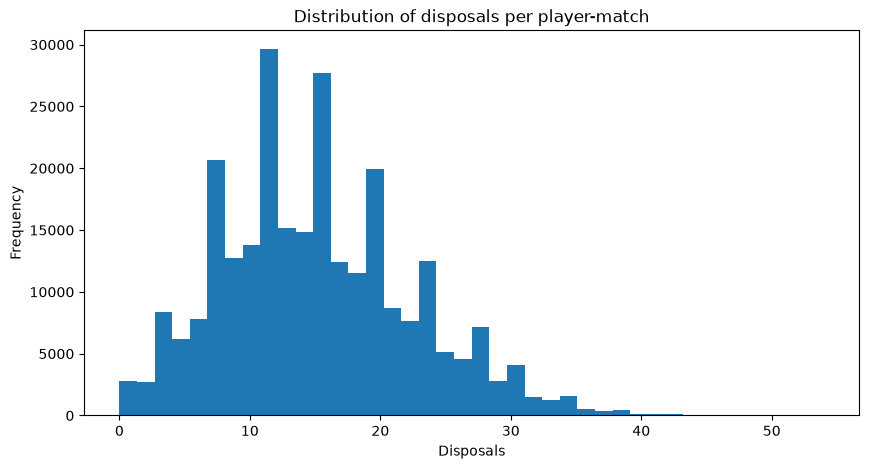

In [40]:
fig, ax = plt.subplots()
rounds['disposals'].dropna().plot(kind='hist', bins=40, ax=ax)
ax.set_title('Distribution of disposals per player-match')
ax.set_xlabel('Disposals')
plt.show()


### 3.5 Week-to-week player consistency

How stable is a player's output game to game? Using the coefficient of variation (std / mean) of
`fantasy_points` for players with a reasonable sample size (≥50 games):


Median week-to-week coefficient of variation: 0.372
-> even established players vary ~35-40% game to game — 'top player' predictions inherently
   carry a wide error band; a model nailing the exact top scorer every week would be a red flag, not a win.


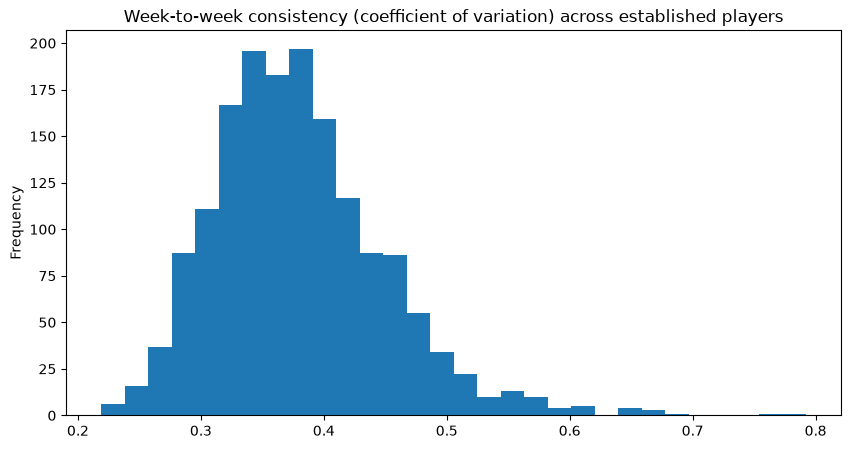

In [41]:
pc = rounds.groupby('player_id')['fantasy_points'].agg(['mean', 'std', 'count'])
pc = pc[pc['count'] >= 50]
pc['cv'] = pc['std'] / pc['mean']
print("Median week-to-week coefficient of variation:", round(pc['cv'].median(), 3))
print("-> even established players vary ~35-40% game to game — 'top player' predictions inherently")
print("   carry a wide error band; a model nailing the exact top scorer every week would be a red flag, not a win.")

fig, ax = plt.subplots()
pc['cv'].plot(kind='hist', bins=30, ax=ax)
ax.set_title('Week-to-week consistency (coefficient of variation) across established players')
plt.show()


### 3.6 Position-based differences: a real data limitation, handled honestly

**None of the five files contain a `position` column.** Rather than fabricate one, we derive a lightweight
*proxy* role from each player's career stat profile — this is a documented assumption, not ground truth,
and should not be presented as official position data downstream.


In [42]:
career = rounds.groupby('player_id')[['hit_outs', 'inside_50s', 'rebound_50s', 'clearances', 'contested_possessions']].mean()
career = career.dropna(thresh=3)  # need at least some of these advanced stats available

def proxy_role(row):
    scores = {
        'Ruck': row['hit_outs'] if pd.notna(row['hit_outs']) else -1,
        'Forward': row['inside_50s'] if pd.notna(row['inside_50s']) else -1,
        'Defender': row['rebound_50s'] if pd.notna(row['rebound_50s']) else -1,
        'Midfielder': (row['clearances'] if pd.notna(row['clearances']) else 0) +
                      (row['contested_possessions'] if pd.notna(row['contested_possessions']) else 0),
    }
    return max(scores, key=scores.get)

career['proxy_role'] = career.apply(proxy_role, axis=1)
role_fp = career.merge(rounds.groupby('player_id')['fantasy_points'].mean().rename('avg_fp'), on='player_id')
print(role_fp.groupby('proxy_role')['avg_fp'].agg(['mean', 'count']).round(1))
print()
print("Read this as a rough directional signal only — a heuristic proxy on ~", len(career),
      "players with sufficient advanced-stat history (mostly post-2000), not a validated position label.")


            mean  count
proxy_role             
Defender    41.4     34
Forward     31.3     51
Midfielder  54.6   2682
Ruck        54.2    237

Read this as a rough directional signal only — a heuristic proxy on ~ 3004 players with sufficient advanced-stat history (mostly post-2000), not a validated position label.


### 3.7 Recent form vs. win probability

This is the relationship the whole feature-engineering task depends on — does a team's recent form actually
predict the next result? (Rolling form is computed properly with no leakage in Task 4; this is a preview
using the same shift-then-roll logic.)


C:\Users\ridan\AppData\Local\Temp\ipykernel_16344\1142631410.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  form_curve = merged_preview.groupby('form_bucket', observed=True).apply(lambda d: (d.target_result == 'HOME_WIN').mean())


form_bucket
(-0.01, 0.2]    0.445
(0.2, 0.4]      0.560
(0.4, 0.6]      0.631
(0.6, 0.8]      0.736
(0.8, 1.01]     0.746
dtype: float64


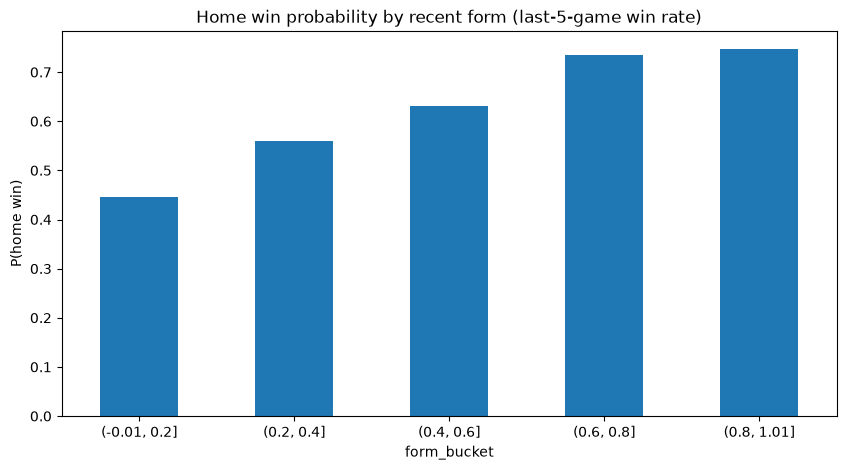

In [43]:
long_preview = pd.concat([
    matches.assign(team=matches.home_team, win=(matches.target_result=='HOME_WIN').astype(int)),
    matches.assign(team=matches.away_team, win=(matches.target_result=='AWAY_WIN').astype(int)),
]).sort_values(['team', 'match_date'])

long_preview['form5'] = (long_preview.groupby('team')['win']
                          .transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean()))

merged_preview = matches.merge(
    long_preview[long_preview.team.notna()][['match_id', 'team', 'form5']]
    .rename(columns={'team': 'home_team', 'form5': 'form5_home'}),
    on=['match_id', 'home_team'], how='left')

merged_preview['form_bucket'] = pd.cut(merged_preview['form5_home'], bins=[-0.01, 0.2, 0.4, 0.6, 0.8, 1.01])
form_curve = merged_preview.groupby('form_bucket', observed=True).apply(lambda d: (d.target_result == 'HOME_WIN').mean())
print(form_curve.round(3))

fig, ax = plt.subplots()
form_curve.plot(kind='bar', ax=ax)
ax.set_ylabel('P(home win)')
ax.set_title('Home win probability by recent form (last-5-game win rate)')
plt.xticks(rotation=0)
plt.show()


A clean, roughly monotonic relationship — teams on strong recent form (0.8+ win rate in the last 5) win
close to 75% of the time, versus ~45% for teams on poor form. This validates rolling form as a genuinely
useful feature rather than noise.

### 3.8 Days of rest vs. win rate


C:\Users\ridan\AppData\Local\Temp\ipykernel_16344\775534312.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rest_curve = rest_preview.groupby('rest_bucket', observed=True).apply(lambda d: (d.target_result == 'HOME_WIN').mean())


rest_bucket
(0, 5]      0.555
(5, 6]      0.581
(6, 7]      0.590
(7, 8]      0.604
(8, 10]     0.567
(10, 30]    0.640
dtype: float64


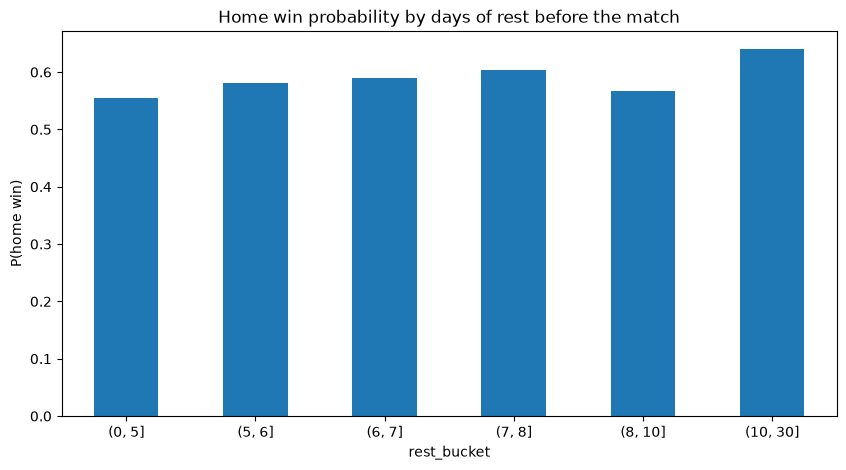

In [44]:
long_preview['days_rest'] = long_preview.groupby('team')['match_date'].transform(lambda s: s.diff().dt.days)
rest_preview = matches.merge(
    long_preview[['match_id', 'team', 'days_rest']].rename(columns={'team': 'home_team', 'days_rest': 'rest_home'}),
    on=['match_id', 'home_team'], how='left')
rest_preview['rest_bucket'] = pd.cut(rest_preview['rest_home'], bins=[0, 5, 6, 7, 8, 10, 30])
rest_curve = rest_preview.groupby('rest_bucket', observed=True).apply(lambda d: (d.target_result == 'HOME_WIN').mean())
print(rest_curve.round(3))

fig, ax = plt.subplots()
rest_curve.plot(kind='bar', ax=ax)
ax.set_ylabel('P(home win)')
ax.set_title('Home win probability by days of rest before the match')
plt.xticks(rotation=0)
plt.show()


Weaker and noisier relationship than form — rest mostly clusters around the standard 6-7 day cycle, with
only bye-week/rescheduled games giving longer rest. Worth keeping as a feature, but don't expect it to carry
much weight relative to form and ladder position.


## Task 4: Feature Engineering for Prediction

**The single hard rule for every feature below: `shift(1)` before any rolling/cumulative computation.**
A match's own result must never be visible in its own feature row. Every rolling function here shifts by one
match *before* windowing — this is verified explicitly at the end of this section, not just asserted.

### 4.1 Team-side rolling form (leakage-safe)


In [45]:
def team_long_format(matches):
    """One row per team-per-match — needed to compute each team's own rolling history."""
    h = matches[['match_id', 'match_date', 'year', 'round', 'home_team', 'away_team',
                 'home_score', 'away_score', 'target_result']].copy()
    h['team'], h['opponent'] = h['home_team'], h['away_team']
    h['team_score'], h['opp_score'] = h['home_score'], h['away_score']
    h['is_home'] = 1
    h['win'] = (h['target_result'] == 'HOME_WIN').astype(int)
    h['draw'] = (h['target_result'] == 'DRAW').astype(int)

    a = matches[['match_id', 'match_date', 'year', 'round', 'home_team', 'away_team',
                 'home_score', 'away_score', 'target_result']].copy()
    a['team'], a['opponent'] = a['away_team'], a['home_team']
    a['team_score'], a['opp_score'] = a['away_score'], a['home_score']
    a['is_home'] = 0
    a['win'] = (a['target_result'] == 'AWAY_WIN').astype(int)
    a['draw'] = (a['target_result'] == 'DRAW').astype(int)

    long = pd.concat([h, a], ignore_index=True)
    long['margin'] = long['team_score'] - long['opp_score']
    return long.sort_values(['team', 'match_date']).reset_index(drop=True)

long = team_long_format(matches)

def add_rolling_form(long, n=5):
    g = long.groupby('team')
    # shift(1) FIRST, then roll — the current match's own outcome is excluded from its own feature
    long[f'form_win_rate_last{n}'] = g['win'].transform(lambda s: s.shift(1).rolling(n, min_periods=1).mean())
    long[f'form_avg_score_last{n}'] = g['team_score'].transform(lambda s: s.shift(1).rolling(n, min_periods=1).mean())
    long[f'form_avg_margin_last{n}'] = g['margin'].transform(lambda s: s.shift(1).rolling(n, min_periods=1).mean())

    def signed_streak(s):
        """+N = N straight wins coming in, -N = N straight losses coming in. Built on shift(1) only."""
        vals = s.shift(1).tolist()
        out, cur, last = [], 0, None
        for v in vals:
            if pd.isna(v):
                out.append(np.nan); cur, last = 0, None; continue
            cur = cur + 1 if (last is None or v == last) else 1
            out.append(cur if v == 1 else -cur)
            last = v
        return out
    long['win_streak'] = g['win'].transform(signed_streak)
    long['days_rest'] = g['match_date'].transform(lambda s: s.diff().dt.days)
    return long

long = add_rolling_form(long, n=5)
print(long[['team', 'match_date', 'win', 'form_win_rate_last5', 'win_streak', 'days_rest']].head(8))


             team match_date  win  form_win_rate_last5  win_streak  days_rest
0  Adelaide Crows 1991-03-22    1                  NaN         NaN        NaN
1  Adelaide Crows 1991-03-31    0             1.000000         1.0        9.0
2  Adelaide Crows 1991-04-07    1             0.500000        -1.0        7.0
3  Adelaide Crows 1991-04-13    0             0.666667         1.0        6.0
4  Adelaide Crows 1991-04-21    0             0.500000        -1.0        8.0
5  Adelaide Crows 1991-04-28    1             0.400000        -2.0        7.0
6  Adelaide Crows 1991-05-04    0             0.400000         1.0        6.0
7  Adelaide Crows 1991-05-17    0             0.400000        -1.0       13.0


### 4.2 Ladder position at time of match (season-cumulative, leakage-safe)

4 points for a win, 2 for a draw, 0 for a loss — standard AFL ladder points — accumulated **within season**,
shifted so the current match's own result isn't counted toward the ladder position used to predict it.

**Bug caught and fixed during review:** the first version of this feature ranked each team's points only
against its *own match's opponent* (grouping by `match_id`, which only ever contains 2 rows) — that just
recovers "is this team currently ahead of the specific team it's about to play," not a real ladder position.
A genuine ladder position has to rank a team against the **entire competition** at the same point in the
season, i.e. group by `(year, round)`, not `(year, match_id)`.


In [46]:
long['points'] = long['win'] * 4 + long['draw'] * 2
long['season_points_before'] = (
    long.sort_values(['team', 'year', 'match_date'])
        .groupby(['team', 'year'])['points']
        .transform(lambda s: s.shift(1).cumsum().fillna(0))
)
# Rank across ALL teams active that round, not just the 2 teams in a given match.
# Caveat: this assumes teams entering the same round-label have played the same number of
# prior games, which holds for standard home-and-away rounds but can be approximate around
# bye rounds (introduced 2023+) and finals, where round labels aren't a clean count of games played.
long['ladder_pos_before'] = (
    long.groupby(['year', 'round'])['season_points_before']
        .rank(ascending=False, method='min')
)
print(long[['team', 'year', 'round', 'season_points_before', 'ladder_pos_before']].head(5))
print("\nladder_pos_before range by a sample season (2019, sanity check against known team count):")
print(long[long.year == 2019]['ladder_pos_before'].agg(['min', 'max']))


             team  year round  season_points_before  ladder_pos_before
0  Adelaide Crows  1991     1                   0.0                1.0
1  Adelaide Crows  1991     2                   4.0                1.0
2  Adelaide Crows  1991     3                   4.0                1.0
3  Adelaide Crows  1991     4                   8.0                1.0
4  Adelaide Crows  1991     5                   8.0                5.0

ladder_pos_before range by a sample season (2019, sanity check against known team count):
min     1.0
max    18.0
Name: ladder_pos_before, dtype: float64


### 4.3 Head-to-head record (all prior meetings between these two specific teams)


In [47]:
long_sorted = long.sort_values('match_date').reset_index(drop=True)
history = {}
h2h_win_rate = []
for row in long_sorted.itertuples():
    key = tuple(sorted([row.team, row.opponent]))
    past = history.get(key, [])
    if past:
        wins_for_team = sum(1 for (_, winner) in past if winner == row.team)
        h2h_win_rate.append(wins_for_team / len(past))
    else:
        h2h_win_rate.append(np.nan)
    winner = row.team if row.win == 1 else (row.opponent if row.draw == 0 else None)
    history.setdefault(key, []).append((row.match_date, winner))
long_sorted['h2h_win_rate_prior'] = h2h_win_rate
print("Rows with no prior meeting yet (expected NaN, first-ever fixture for that pairing):",
      long_sorted['h2h_win_rate_prior'].isna().sum())


Rows with no prior meeting yet (expected NaN, first-ever fixture for that pairing): 182


### 4.4 Interstate travel flag (from Task 3.3, formalized as a feature)

In [48]:
long_sorted['venue_state'] = long_sorted.merge(
    matches[['match_id', 'venue']], on='match_id', how='left')['venue'].map(VENUE_STATE)
long_sorted['team_state'] = long_sorted['team'].map(TEAM_STATE)
long_sorted['is_interstate'] = (long_sorted['team_state'] != long_sorted['venue_state']).astype('Int64')
long_sorted.loc[long_sorted['venue_state'].isna(), 'is_interstate'] = pd.NA
print(long_sorted['is_interstate'].value_counts(dropna=False))


is_interstate
0       10784
1        4930
<NA>       94
Name: count, dtype: Int64


### 4.5 Assemble the match-level feature table (home + away side by side)


In [ ]:
feat_cols = ['match_id', 'team', 'form_win_rate_last5', 'form_avg_score_last5', 'form_avg_margin_last5',
             'win_streak', 'days_rest', 'ladder_pos_before', 'h2h_win_rate_prior', 'is_interstate']

home_feat = (long_sorted[long_sorted['is_home'] == 1][feat_cols]
             .add_suffix('_home').rename(columns={'match_id_home': 'match_id'}))
away_feat = (long_sorted[long_sorted['is_home'] == 0][feat_cols]
             .add_suffix('_away').rename(columns={'match_id_away': 'match_id'}))

match_features = (matches
                   .merge(home_feat, on='match_id', how='left')
                   .merge(away_feat, on='match_id', how='left'))

print(match_features.shape, "rows -- must equal", matches.shape[0], "(one row per match, no fan-out)")
assert match_features.shape[0] == matches.shape[0]
match_features.head(3)


(7904, 36) rows -- must equal 7904 (one row per match, no fan-out)


,match_id,match_date,year,round,venue,crowd,home_team,away_team,home_score,away_score,margin_home,is_final,target_result,target_margin,decade,venue_state,away_team_state,away_is_interstate,team_home,form_win_rate_last5_home,form_avg_score_last5_home,form_avg_margin_last5_home,win_streak_home,days_rest_home,ladder_pos_before_home,h2h_win_rate_prior_home,is_interstate_home,team_away,form_win_rate_last5_away,form_avg_score_last5_away,form_avg_margin_last5_away,win_streak_away,days_rest_away,ladder_pos_before_away,h2h_win_rate_prior_away,is_interstate_away
0,Collingwood Magpies_Melbourne Demons_1983-03-26_1,1983-03-26,1983,1,Melbourne Cricket Ground,72274.0,Melbourne Demons,Collingwood Magpies,125,135,-10,False,AWAY_WIN,-10,1980,VIC,VIC,0,Melbourne Demons,NaN,NaN,NaN,NaN,NaN,1.0,NaN,0,Collingwood Magpies,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0
1,Carlton Blues_Richmond Tigers_1983-03-26_1,1983-03-26,1983,1,Princes Park,28498.0,Carlton Blues,Richmond Tigers,136,76,60,False,HOME_WIN,60,1980,VIC,VIC,0,Carlton Blues,NaN,NaN,NaN,NaN,NaN,1.0,NaN,0,Richmond Tigers,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0
2,Fitzroy Lions_Hawthorn Hawks_1983-03-26_1,1983-03-26,1983,1,Junction Oval,15626.0,Fitzroy Lions,Hawthorn Hawks,112,131,-19,False,AWAY_WIN,-19,1980,VIC,VIC,0,Fitzroy Lions,NaN,NaN,NaN,NaN,NaN,1.0,NaN,0,Hawthorn Hawks,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0


### 4.6 Player-side rolling features (same leakage rule, per player)


In [29]:
rounds['match_date'] = pd.to_datetime(rounds['match_date'])
rounds_sorted = rounds.sort_values(['player_id', 'match_date']).reset_index(drop=True)
g = rounds_sorted.groupby('player_id')
for col in ['disposals', 'goals', 'fantasy_points']:
    rounds_sorted[f'player_avg_{col}_last5'] = g[col].transform(
        lambda s: s.shift(1).rolling(5, min_periods=1).mean())

first_games = rounds_sorted.sort_values(['player_id', 'match_date']).groupby('player_id').head(1)
print("Null rate of player_avg_disposals_last5 on each player's true FIRST game (must be ~100%):",
      round(first_games['player_avg_disposals_last5'].isna().mean(), 3))


Null rate of player_avg_disposals_last5 on each player's true FIRST game (must be ~100%): 1.0


### 4.7 Explicit leakage audit

Two independent checks that no feature can see its own match's outcome:


In [30]:
# Check 1: a team's very first appearance in the dataset must have NaN form/streak (no history exists yet)
first_team_rows = long_sorted.sort_values('match_date').groupby('team').head(1)
print("form_win_rate_last5 null-rate on each team's first-ever match:", first_team_rows['form_win_rate_last5'].isna().mean())
print("win_streak null-rate on each team's first-ever match:", first_team_rows['win_streak'].isna().mean())

# Check 2: manually recompute form for one team's Nth match using only STRICTLY EARLIER matches, compare
sample_team = 'Hawthorn Hawks'
th = long_sorted[long_sorted.team == sample_team].sort_values('match_date').reset_index(drop=True)
idx = 10  # arbitrary match, well past the team's start
manual_form = th.loc[max(0, idx-5):idx-1, 'win'].mean()
pipeline_form = th.loc[idx, 'form_win_rate_last5']
print(f"\nManual recompute (using only matches BEFORE row {idx}): {manual_form:.3f}")
print(f"Pipeline value at row {idx}: {pipeline_form:.3f}")
assert abs(manual_form - pipeline_form) < 1e-9, "LEAKAGE DETECTED — values should match exactly"
print("Match confirmed — no leakage.")


form_win_rate_last5 null-rate on each team's first-ever match: 1.0
win_streak null-rate on each team's first-ever match: 1.0

Manual recompute (using only matches BEFORE row 10): 0.400
Pipeline value at row 10: 0.400
Match confirmed — no leakage.


### 4.8 Feature dictionary

| Feature | Description | Computation window | Source columns |
|---|---|---|---|
| `form_win_rate_last5_{home,away}` | Win rate in team's last 5 matches, prior to this one | rolling 5, `shift(1)` | `team_matches.result` |
| `form_avg_score_last5_{home,away}` | Avg points scored, last 5 matches | rolling 5, `shift(1)` | `team_matches.team_score` |
| `form_avg_margin_last5_{home,away}` | Avg signed margin, last 5 matches | rolling 5, `shift(1)` | derived |
| `win_streak_{home,away}` | Signed current streak (+wins / −losses) coming in | all history, `shift(1)` | `team_matches.result` |
| `days_rest_{home,away}` | Days since team's previous match | 1-lag diff | `team_matches.match_date` |
| `ladder_pos_before_{home,away}` | Ladder rank within season, before this round | season-cumulative, `shift(1)` | derived from `result` |
| `h2h_win_rate_prior_{home,away}` | Win rate vs. this specific opponent, all prior meetings | full history, strictly prior | `team_matches.result` |
| `is_interstate_{home,away}` | 1 if team is playing outside its home state | static team/venue → state map | `team_matches.venue`, static map |
| `player_avg_disposals_last5` | Player's avg disposals, last 5 games | rolling 5, `shift(1)` | `rounds.disposals` |
| `player_avg_goals_last5` | Player's avg goals, last 5 games | rolling 5, `shift(1)` | `rounds.goals` |
| `player_avg_fantasy_points_last5` | Player's avg fantasy score, last 5 games | rolling 5, `shift(1)` | `rounds.fantasy_points` |

### 4.9 Save the versioned feature table


In [31]:
match_features.to_parquet('feature_table_matches_v1.parquet', index=False)
match_features.to_csv('feature_table_matches_v1.csv', index=False)
rounds_sorted.to_parquet('feature_table_players_v1.parquet', index=False)
rounds_sorted.to_csv('feature_table_players_v1.csv', index=False)
print("Saved: feature_table_matches_v1.[parquet|csv], feature_table_players_v1.[parquet|csv]")


Saved: feature_table_matches_v1.[parquet|csv], feature_table_players_v1.[parquet|csv]


## Task 5 — Reproducible Train/Hold-Out Split

### 5.1 Why a random split leaks in this dataset

Ladder position, form, and head-to-head are all **season-accumulating** — a match's features literally
encode "what has happened in this competition so far this year." A random 80/20 split would put, say,
Round 3 of 2024 in the test set while Round 20 of 2024 (which used information from Round 3 onward) sits in
training. The model would implicitly see the season's trajectory before being asked to predict its earlier
rounds. In a genuinely time-ordered domain, the only safe split is **strictly by time**.

### 5.2 The reusable split function


In [32]:
def time_based_split(df, date_col='match_date', holdout_seasons=1, year_col='year'):
    """
    Train on every season except the most recent `holdout_seasons`.
    Every model built this week should call this SAME function so results are comparable
    and no model accidentally trains on data another model is being tested against.
    """
    max_year = df[year_col].max()
    cutoff = max_year - holdout_seasons + 1
    train = df[df[year_col] < cutoff].copy()
    test = df[df[year_col] >= cutoff].copy()
    return train, test

train_matches, test_matches = time_based_split(match_features)
print(f"Train: {len(train_matches)} matches ({train_matches.year.min()}-{train_matches.year.max()})")
print(f"Test:  {len(test_matches)} matches ({test_matches.year.min()}-{test_matches.year.max()})")

# same function, same contract, for the player-level table
train_players, test_players = time_based_split(rounds_sorted)
print(f"\nPlayer train: {len(train_players)} rows, player test: {len(test_players)} rows")


Train: 7688 matches (1983-2024)
Test:  216 matches (2025-2025)

Player train: 264143 rows, player test: 9936 rows


### 5.3 What's a realistic accuracy ceiling here?

The naive baseline — always pick the home team — already gets roughly **59%** accuracy purely from home
ground advantage, so that's the floor any model needs to beat, not 50%. Realistically, published AFL
prediction models (including professional betting-market-calibrated ones) land in the **65–72%** range for
match-winner classification; sports outcomes have genuine, irreducible randomness from injuries, umpiring
decisions, and weather that no pre-match feature set can capture. If a model on this data reports 90%+
accuracy on the holdout set, that is a **red flag for leakage** — most likely a feature computed with
`shift(0)` instead of `shift(1)` somewhere, or accidental use of same-day information (e.g. final scores)
in a "pre-match" feature. Perfect or near-perfect accuracy in sports prediction should trigger suspicion
before celebration.
